# Dynamo Sandbox

Interactive notebook for inspecting data loading, fragment sampling, evaluation pipeline, and visualization panels.

**Kernel**: Use the `vae-env-cluster` environment.

**Sections**:
- 1–8: Data loading, trajectory visualization, PCA diagnostics, fragment sampling
- 9–10: Evaluation pipeline — dummy predictors, metrics, run_evaluation(), comparison tables
- 11–12: Visualization panels — trajectory view, prediction fan, phenotype space, three-panel figure
- 13: Simple kernel baseline — construction, prediction fans, evaluation, per-horizon comparison

In [1]:
import sys
from pathlib import Path

# Ensure repo root is importable
REPO_ROOT = Path.cwd()
while not (REPO_ROOT / ".git").exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

BUILD_DIR = REPO_ROOT / "morphseq_playground" / "metadata" / "build06_output"
print(f"Repo root: {REPO_ROOT}")
print(f"Build dir: {BUILD_DIR}")
print(f"Available: {BUILD_DIR.exists()}")

Repo root: /home/nick/projects/morphseq
Build dir: /home/nick/projects/morphseq/morphseq_playground/metadata/build06_output
Available: True


## 1. Load Trajectories

Load one or more experiments and project `z_mu_b` columns into PC space.

In [2]:
from dev.dynamo.data.loading import load_trajectories

EXPERIMENT_IDS = ["20251207_pbx"]
N_COMPONENTS = 10

ds = load_trajectories(
    # experiment_ids=EXPERIMENT_IDS,
    build_dir=BUILD_DIR,
    n_components=N_COMPONENTS,
    verbose=True,
)

  Auto-discovered 40 experiments in /home/nick/projects/morphseq/morphseq_playground/metadata/build06_output
  Loaded 20230525: 2684 rows
  Loaded 20230531: 3591 rows
  Loaded 20230613: 3935 rows
  Loaded 20230615: 2724 rows
  Loaded 20230622: 2316 rows
  Loaded 20230627: 3005 rows
  Loaded 20230629: 1556 rows
  Loaded 20231206: 3048 rows
  Loaded 20231218: 1836 rows
  Loaded 20240418: 4734 rows
  Loaded 20250305: 13847 rows
  Loaded 20250415: 2950 rows
  Loaded 20250416: 4314 rows
  Loaded 20250425: 4837 rows
  Loaded 20250512: 9089 rows
  Loaded 20250515_part2: 1439 rows
  Loaded 20250519: 3603 rows
  Loaded 20250520: 1415 rows
  Loaded 20250529_24hpf_ctrl_atf6: 89 rows
  Loaded 20250529_36hpf_ctrl_atf6: 67 rows
  Loaded 20250711: 10486 rows
  Loaded 20250711.archive: 1611 rows
  Loaded 20250912: 1952 rows
  Loaded 20251017_combined: 5663 rows
  Loaded 20251017_part1: 4124 rows
  Loaded 20251017_part2: 2103 rows
  Loaded 20251020: 1411 rows
  Loaded 20251104: 1476 rows
  Loaded 20251

In [3]:
ds.trajectories[0].trajectory.shape

(61, 10)

In [4]:
import numpy as np

print(f"Trajectories: {len(ds)}")
print(f"PC dimensions: {ds.n_components}")
print(f"Classes: {ds.class_names}")
print(f"Class → idx: {ds.class_to_idx}")
print()

# Per-class summary
from collections import Counter
class_counts = Counter(t.perturbation_class for t in ds.trajectories)
lengths = [len(t.trajectory) for t in ds.trajectories]
for cls, count in sorted(class_counts.items()):
    cls_lengths = [len(t.trajectory) for t in ds.trajectories if t.perturbation_class == cls]
    print(f"  {cls}: {count} embryos, {np.median(cls_lengths):.0f} median frames")

print(f"\nTrajectory lengths: min={min(lengths)}, median={np.median(lengths):.0f}, max={max(lengths)}")
print(f"PCA variance explained: {ds.pca.explained_variance_ratio_.sum()*100:.1f}%")

Trajectories: 3225
PC dimensions: 10
Classes: ['Uncertain', 'ab', 'b9d2_heterozygous', 'b9d2_homozygous', 'b9d2_unknown', 'b9d2_wildtype', 'cep290_crispant', 'cep290_heterozygous', 'cep290_homozygous', 'cep290_unknown', 'cep290_unknown\xa0', 'cep290_unkown', 'cep290_wildtype', 'crispr-inj-ctrl', 'crispr-pbx1', 'crispr-pbx1+4', 'crispr-pbx4', 'foxj1a_crispant', 'gdf3', 'if88_ift74_crispant', 'ift88_crispant', 'lmx1b', 'noto', 'scospondin_crispant', 'tbxta', 'tmem67_heterozygote', 'tmem67_heterozygous', 'tmem67_homozygous', 'tmem67_unknown', 'tmem67_wildtype', 'wik', 'wik-ab', 'wik-inj-ctrl', 'wt-tbxta']
Class → idx: {'Uncertain': 0, 'ab': 1, 'b9d2_heterozygous': 2, 'b9d2_homozygous': 3, 'b9d2_unknown': 4, 'b9d2_wildtype': 5, 'cep290_crispant': 6, 'cep290_heterozygous': 7, 'cep290_homozygous': 8, 'cep290_unknown': 9, 'cep290_unknown\xa0': 10, 'cep290_unkown': 11, 'cep290_wildtype': 12, 'crispr-inj-ctrl': 13, 'crispr-pbx1': 14, 'crispr-pbx1+4': 15, 'crispr-pbx4': 16, 'foxj1a_crispant': 17

## 2. Visualize Trajectories in PC Space

In [9]:
import plotly.graph_objects as go
import numpy as np

# Color palette per class
COLORS = ["#636EFA", "#EF553B", "#00CC96", "#AB63FA", "#FFA15A", "#19D3F3"]

n_plot = 10
np.random.seed(42)
plot_ids = np.random.choice(np.arange(len(ds.trajectories)), size=n_plot, replace=False)
class_colors = {cls: COLORS[i % len(COLORS)] for i, cls in enumerate(ds.class_names)}
fig = go.Figure()
for id in plot_ids:
    traj = ds.trajectories[id]
    z = traj.trajectory
    fig.add_trace(go.Scatter3d(
        x=z[:, 0], y=z[:, 1], z=z[:, 2],
        mode="lines",
        line=dict(width=2, color=class_colors[traj.perturbation_class]),
        name=traj.perturbation_class,
        legendgroup=traj.perturbation_class,
        showlegend=False,
        hovertext=traj.embryo_id,
    ))

# One legend entry per class
for id in plot_ids:
    traj = ds.trajectories[id]
    cls = traj.perturbation_class
    color = class_colors[cls]
    fig.add_trace(go.Scatter3d(
        x=[None], y=[None], z=[None],
        mode="markers", marker=dict(size=6, color=color),
        name=cls, legendgroup=cls, showlegend=True,
    ))

var = ds.pca.explained_variance_ratio_ * 100
fig.update_layout(
    title="Embryo Trajectories in PC Space",
    scene=dict(
        xaxis_title=f"PC1 ({var[0]:.1f}%)",
        yaxis_title=f"PC2 ({var[1]:.1f}%)",
        zaxis_title=f"PC3 ({var[2]:.1f}%)",
    ),
    width=800, height=600,
)
fig.show()

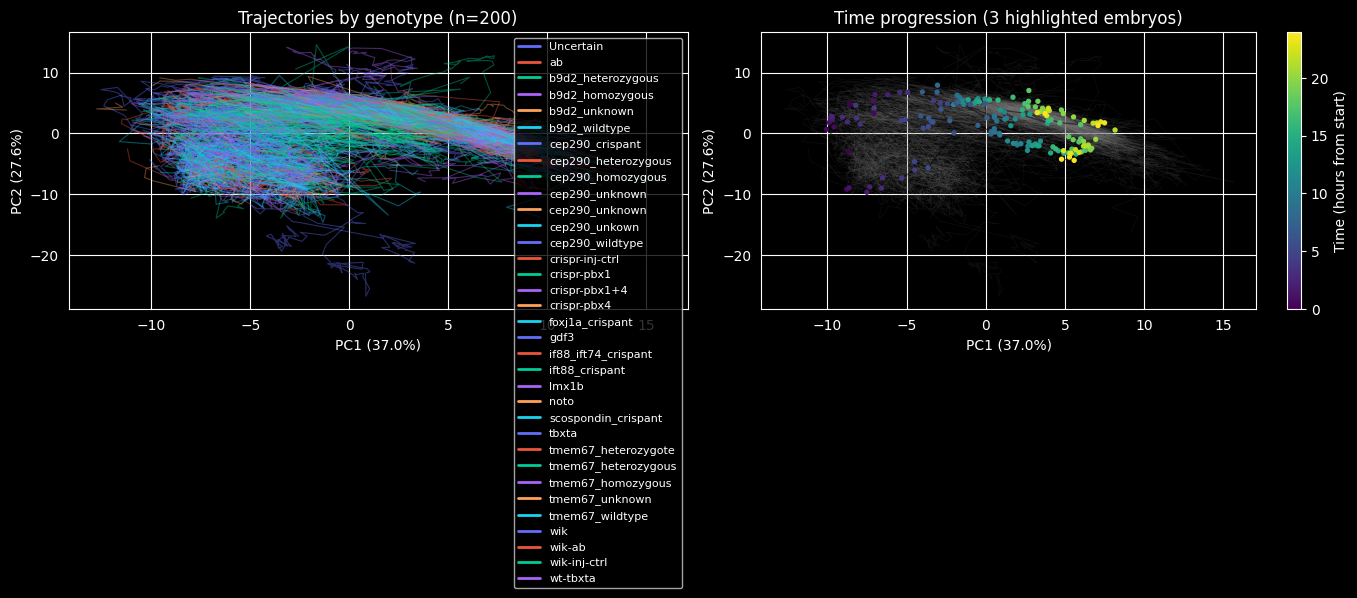

In [10]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

N_SAMPLE = 200  # adjust as needed

rng = np.random.default_rng(42)
sample_idxs = rng.choice(len(ds.trajectories), size=min(N_SAMPLE, len(ds.trajectories)), replace=False)
sampled_trajectories = [ds.trajectories[i] for i in sample_idxs]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: colored by genotype
ax = axes[0]
for traj in sampled_trajectories:
    z = traj.trajectory
    ax.plot(z[:, 0], z[:, 1], alpha=0.4, linewidth=0.8,
            color=class_colors[traj.perturbation_class])
for cls, color in class_colors.items():
    ax.plot([], [], color=color, label=cls, linewidth=2)
ax.legend(fontsize=8)
ax.set_xlabel(f"PC1 ({var[0]:.1f}%)")
ax.set_ylabel(f"PC2 ({var[1]:.1f}%)")
ax.set_title(f"Trajectories by genotype (n={len(sampled_trajectories)})")

# Right: colored by time
ax = axes[1]
for traj in sampled_trajectories:
    ax.plot(traj.trajectory[:, 0], traj.trajectory[:, 1],
            alpha=0.1, linewidth=0.5, color="gray")
highlight_idxs = rng.choice(len(sampled_trajectories), size=min(3, len(sampled_trajectories)), replace=False)
for idx in highlight_idxs:
    traj = sampled_trajectories[idx]
    z = traj.trajectory
    t = (traj.time_seconds - traj.time_seconds[0]) / 3600
    sc = ax.scatter(z[:, 0], z[:, 1], c=t, cmap="viridis", s=8, zorder=5)
    ax.plot(z[:, 0], z[:, 1], alpha=0.5, linewidth=1, color="black", zorder=4)
plt.colorbar(sc, ax=ax, label="Time (hours from start)")
ax.set_xlabel(f"PC1 ({var[0]:.1f}%)")
ax.set_ylabel(f"PC2 ({var[1]:.1f}%)")
ax.set_title("Time progression (3 highlighted embryos)")

plt.tight_layout()
plt.show()

## 3. PCA Diagnostics

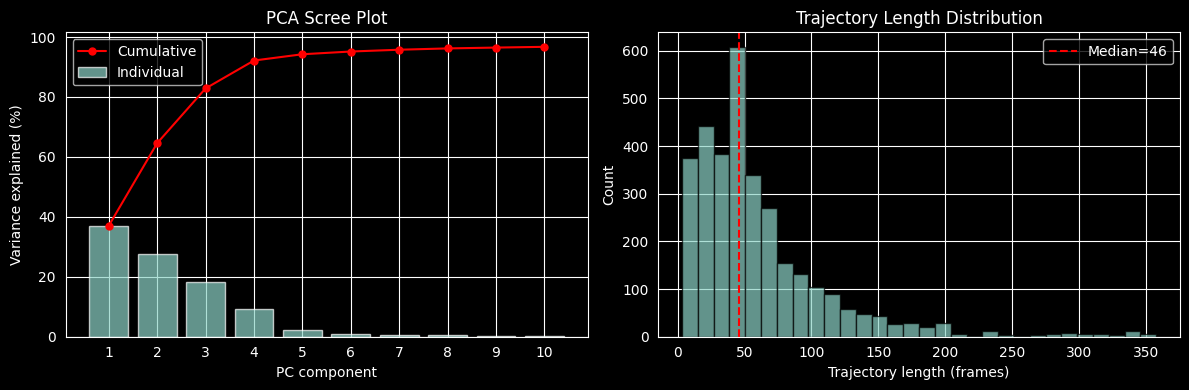

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Scree plot
ax = axes[0]
var_exp = ds.pca.explained_variance_ratio_ * 100
cum_var = np.cumsum(var_exp)
ax.bar(range(1, len(var_exp)+1), var_exp, alpha=0.7, label="Individual")
ax.plot(range(1, len(var_exp)+1), cum_var, "ro-", markersize=5, label="Cumulative")
ax.set_xlabel("PC component")
ax.set_ylabel("Variance explained (%)")
ax.set_title("PCA Scree Plot")
ax.legend()
ax.set_xticks(range(1, len(var_exp)+1))

# Trajectory length distribution
ax = axes[1]
lengths = [len(t.trajectory) for t in ds.trajectories]
ax.hist(lengths, bins=30, edgecolor="black", alpha=0.7)
ax.axvline(np.median(lengths), color="red", linestyle="--", label=f"Median={np.median(lengths):.0f}")
ax.set_xlabel("Trajectory length (frames)")
ax.set_ylabel("Count")
ax.set_title("Trajectory Length Distribution")
ax.legend()

plt.tight_layout()
plt.show()

## 4. Fragment Sampling Demo

Create a `FragmentDataset` and draw sample batches.

In [12]:
from dev.dynamo.data.dataset import FragmentDataset, fragment_collate_fn, worker_init_fn
from torch.utils.data import DataLoader

fds = FragmentDataset(
    ds,
    min_context=3,
    max_context=20,
    horizons=(1, 2, 3, 4),
    epoch_length=256,
)

loader = DataLoader(
    fds,
    batch_size=16,
    collate_fn=fragment_collate_fn,
    num_workers=0,
)

print(f"Dataset length (epoch): {len(fds)}")
print(f"Valid trajectories: {len(fds.valid_indices)} / {len(ds.trajectories)}")
print(f"Batches per epoch: {len(fds) // 16}")

Dataset length (epoch): 256
Valid trajectories: 3197 / 3225
Batches per epoch: 16


In [13]:
# Draw one batch and inspect
batch = next(iter(loader))

print("Batch contents:")
print(f"  context:      {batch.context.shape}  (B, L_max, D)")
print(f"  context_mask: {batch.context_mask.shape}  (B, L_max)")
print(f"  target:       {batch.target.shape}  (B, D)")
print(f"  time_deltas:  {batch.time_deltas.shape}  (B, L_max-1)")
print(f"  horizon_dt:   {batch.horizon_dt.shape}  (B,)")
print(f"  delta_t:      {batch.delta_t.shape}  (B,)")
print(f"  temperature:  {batch.temperature.shape}  (B,)")
print(f"  class_idx:    {batch.class_idx.shape}  (B,)")
print(f"  embryo_idx:   {batch.embryo_idx.shape}  (B,)")
print()

# Context lengths in this batch
ctx_lengths = batch.context_mask.sum(dim=1)
print(f"Context lengths: {ctx_lengths.tolist()}")
print(f"Horizon Δt (hours): {(batch.horizon_dt / 3600).tolist()}")
print(f"Classes: {batch.class_idx.tolist()} → {[ds.class_names[i] for i in batch.class_idx.tolist()]}")

Batch contents:
  context:      torch.Size([16, 18, 10])  (B, L_max, D)
  context_mask: torch.Size([16, 18])  (B, L_max)
  target:       torch.Size([16, 10])  (B, D)
  time_deltas:  torch.Size([16, 17])  (B, L_max-1)
  horizon_dt:   torch.Size([16])  (B,)
  delta_t:      torch.Size([16])  (B,)
  temperature:  torch.Size([16])  (B,)
  class_idx:    torch.Size([16])  (B,)
  embryo_idx:   torch.Size([16])  (B,)

Context lengths: [16, 9, 4, 4, 10, 18, 3, 3, 4, 8, 8, 15, 13, 16, 15, 5]
Horizon Δt (hours): [0.35062330961227417, 0.6695202589035034, 6.920330047607422, 0.5928624272346497, 1.0307807922363281, 1.0103726387023926, 1.623963713645935, 2.1694421768188477, 3.0358357429504395, 2.338909149169922, 0.8330363631248474, 1.628197431564331, 0.513857364654541, 2.9392669200897217, 1.026284098625183, 2.69667649269104]
Classes: [7, 6, 21, 11, 5, 29, 9, 30, 30, 26, 30, 8, 11, 30, 11, 2] → ['cep290_heterozygous', 'cep290_crispant', 'lmx1b', 'cep290_unkown', 'b9d2_wildtype', 'tmem67_wildtype', 'cep2

## 5. Visualize Sampled Fragments

Show context fragments (solid) + target points (star) overlaid on the full trajectory cloud.

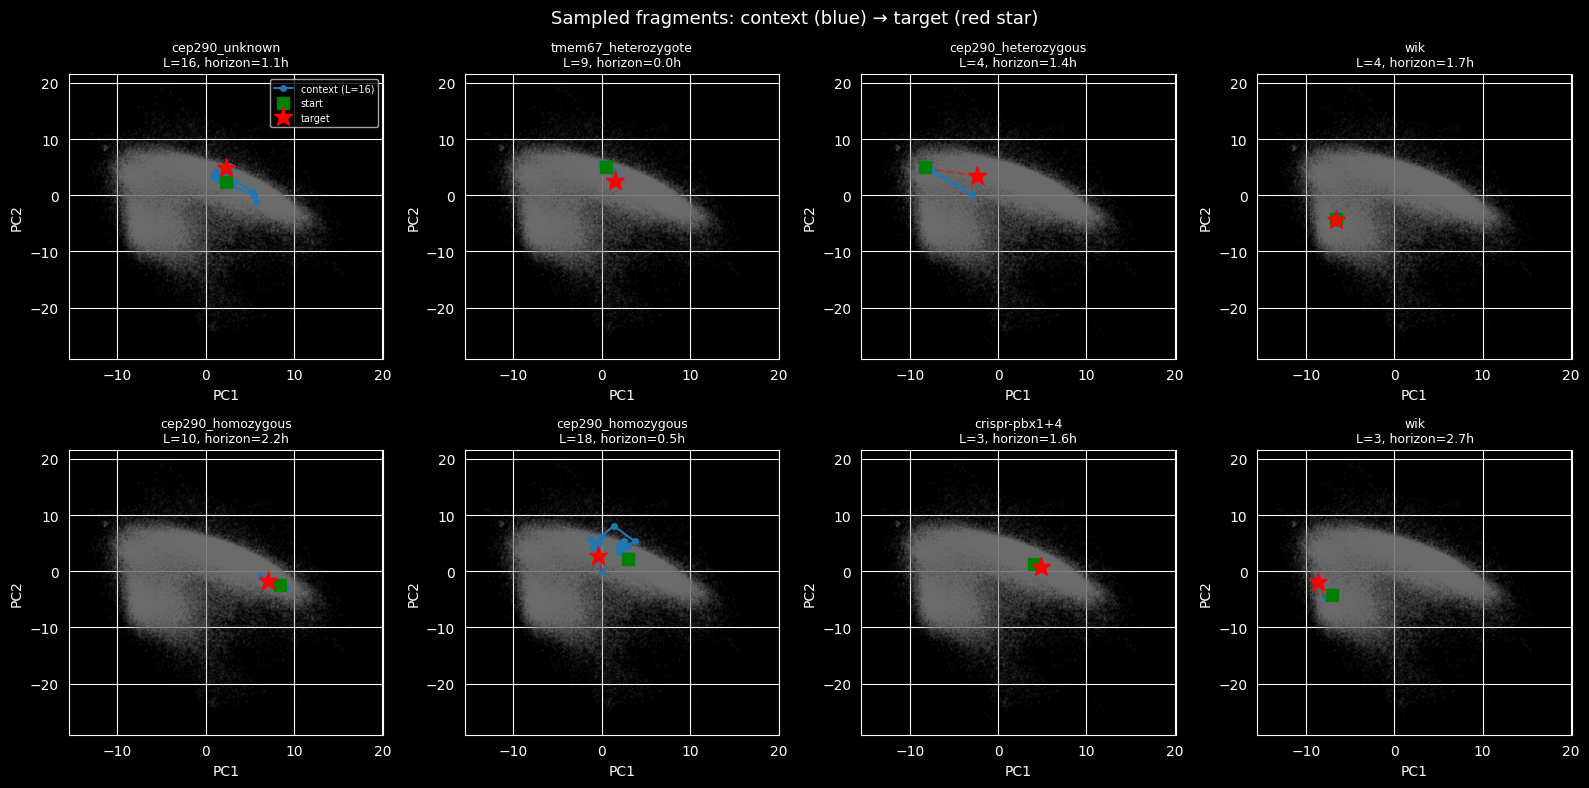

In [16]:
batch = next(iter(loader))

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

# Background: all trajectories in light gray
all_z = np.concatenate([t.trajectory for t in ds.trajectories], axis=0)

for i, ax in enumerate(axes.flat):
    if i >= batch.context.shape[0]:
        ax.set_visible(False)
        continue

    # Background cloud
    ax.scatter(all_z[:, 0], all_z[:, 1], s=0.5, alpha=0.05, color="gray")

    # Context fragment
    L = int(ctx_lengths[i])
    ctx = batch.context[i, :L].numpy()
    tgt = batch.target[i].numpy()
    cls = ds.class_names[batch.class_idx[i]]

    ax.plot(ctx[:, 0], ctx[:, 1], "o-", color="#1f77b4", markersize=4, linewidth=1.5,
            label=f"context (L={L})")
    ax.plot(ctx[0, 0], ctx[0, 1], "s", color="green", markersize=8, zorder=5, label="start")
    ax.plot(tgt[0], tgt[1], "*", color="red", markersize=14, zorder=5, label="target")

    # Dashed line from last context to target
    ax.plot([ctx[-1, 0], tgt[0]], [ctx[-1, 1], tgt[1]], "--", color="red", alpha=0.5)

    h_hrs = batch.horizon_dt[i].item() / 3600
    ax.set_title(f"{cls}\nL={L}, horizon={h_hrs:.1f}h", fontsize=9)
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
    if i == 0:
        ax.legend(fontsize=7, loc="upper right")

plt.suptitle("Sampled fragments: context (blue) → target (red star)", fontsize=13)
plt.tight_layout()
plt.show()

## 6. Batch Statistics Over Many Samples

Aggregate statistics over a full epoch to verify sampling behavior.

In [17]:
# Collect stats over all batches in an epoch
all_ctx_lengths = []
all_horizon_dts = []
all_classes = []
all_time_deltas = []

for batch in loader:
    lengths = batch.context_mask.sum(dim=1)
    all_ctx_lengths.extend(lengths.tolist())
    all_horizon_dts.extend(batch.horizon_dt.tolist())
    all_classes.extend(batch.class_idx.tolist())
    # Collect real (non-padded) time deltas
    for i in range(batch.context.shape[0]):
        L = int(lengths[i])
        if L > 1:
            all_time_deltas.extend(batch.time_deltas[i, :L-1].tolist())

all_ctx_lengths = np.array(all_ctx_lengths)
all_horizon_dts = np.array(all_horizon_dts)
all_classes = np.array(all_classes)

print(f"Total samples: {len(all_ctx_lengths)}")
print(f"Context length — mean: {all_ctx_lengths.mean():.1f}, min: {all_ctx_lengths.min()}, max: {all_ctx_lengths.max()}")
print(f"Horizon Δt — mean: {np.mean(all_horizon_dts)/3600:.2f}h, min: {np.min(all_horizon_dts)/3600:.2f}h, max: {np.max(all_horizon_dts)/3600:.2f}h")

Total samples: 256
Context length — mean: 10.7, min: 3, max: 20
Horizon Δt — mean: 1.67h, min: 0.14h, max: 18.11h


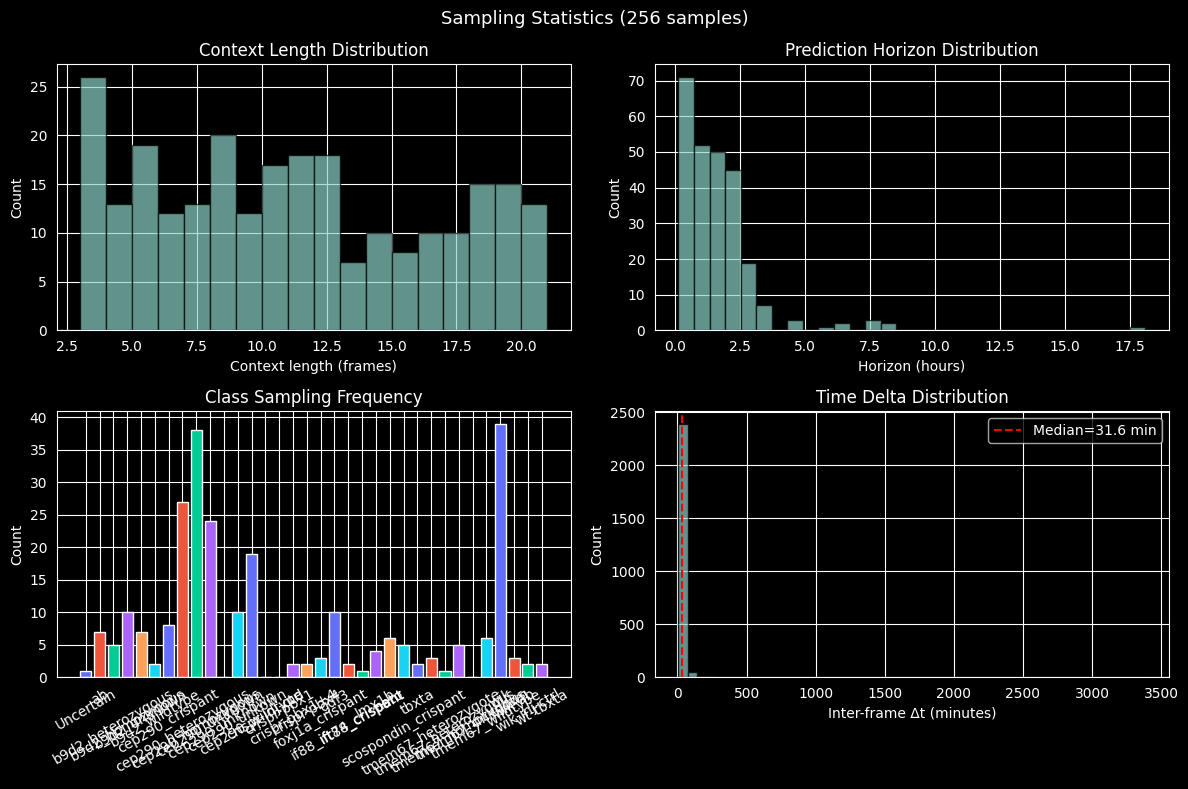

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Context length distribution
ax = axes[0, 0]
ax.hist(all_ctx_lengths, bins=range(int(all_ctx_lengths.min()), int(all_ctx_lengths.max())+2),
        edgecolor="black", alpha=0.7)
ax.set_xlabel("Context length (frames)")
ax.set_ylabel("Count")
ax.set_title("Context Length Distribution")

# Horizon distribution (in units of experiment Δt)
ax = axes[0, 1]
horizon_hours = all_horizon_dts / 3600
ax.hist(horizon_hours, bins=30, edgecolor="black", alpha=0.7)
ax.set_xlabel("Horizon (hours)")
ax.set_ylabel("Count")
ax.set_title("Prediction Horizon Distribution")

# Class sampling frequency
ax = axes[1, 0]
class_freq = np.bincount(all_classes, minlength=len(ds.class_names))
bars = ax.bar(range(len(ds.class_names)), class_freq, tick_label=ds.class_names,
              color=[COLORS[i % len(COLORS)] for i in range(len(ds.class_names))])
ax.set_ylabel("Count")
ax.set_title("Class Sampling Frequency")
ax.tick_params(axis='x', rotation=30)

# Inter-frame Δt distribution
ax = axes[1, 1]
dt_minutes = np.array(all_time_deltas) / 60
ax.hist(dt_minutes, bins=50, edgecolor="black", alpha=0.7)
ax.axvline(np.median(dt_minutes), color="red", linestyle="--",
           label=f"Median={np.median(dt_minutes):.1f} min")
ax.set_xlabel("Inter-frame Δt (minutes)")
ax.set_ylabel("Count")
ax.set_title("Time Delta Distribution")
ax.legend()

plt.suptitle(f"Sampling Statistics ({len(all_ctx_lengths)} samples)", fontsize=13)
plt.tight_layout()
plt.show()

## 7. Multi-Experiment Loading

Demonstrate loading multiple experiments to verify cross-experiment Δt handling.

In [19]:
ds_multi = load_trajectories(
    experiment_ids=["20251207_pbx", "20250305"],
    build_dir=BUILD_DIR,
    n_components=10,
    verbose=True,
)

# Compare Δt across experiments
from collections import defaultdict
dt_by_exp = defaultdict(list)
for t in ds_multi.trajectories:
    dt_by_exp[t.experiment_id].append(t.delta_t)

for exp, dts in dt_by_exp.items():
    print(f"  {exp}: Δt = {dts[0]/60:.1f} min, {len(dts)} embryos")

  Loaded 20251207_pbx: 7177 rows
  Loaded 20250305: 13847 rows
  Filtered use_embryo_flag: 21024 → 21024 rows
  Found 80 z_mu_b columns
  PCA: 10 components, 95.9% variance explained
  Experiment 20250305: median Δt = 492.7s
  Experiment 20251207_pbx: median Δt = 1952.1s
  Built 185 trajectories (dropped 2 with <3 frames)
  Trajectory lengths: min=3, median=87, max=340
  20250305: Δt = 8.2 min, 91 embryos
  20251207_pbx: Δt = 32.5 min, 94 embryos


## 8. DataLoader Integration Test

Verify that full DataLoader iteration works end-to-end with proper batching.

In [20]:
import torch

fds_full = FragmentDataset(ds, min_context=3, max_context=15, horizons=(1, 2, 3, 4), epoch_length=128)

loader_full = DataLoader(
    fds_full,
    batch_size=32,
    collate_fn=fragment_collate_fn,
    num_workers=0,
)

# Iterate full epoch
n_batches = 0
n_samples = 0
for batch in loader_full:
    n_batches += 1
    n_samples += batch.context.shape[0]
    # Verify invariants
    assert batch.context.shape[2] == N_COMPONENTS
    assert batch.target.shape[1] == N_COMPONENTS
    assert (batch.horizon_dt > 0).all()
    assert batch.context_mask.any(dim=1).all()  # every sample has at least 1 real frame

print(f"Iterated {n_batches} batches, {n_samples} total samples")
print("All invariants passed.")

AssertionError: 

In [25]:
batch = next(iter(loader_full))
np.asarray(batch.horizon_dt)

array([  2949.5125,  81231.68  ,   3908.6323,  23425.951 ,   3456.9954,
         4801.4004,   2462.2078,   2726.1997,   7495.9106,   9234.934 ,
         3713.265 ,   2683.4756,   5678.352 ,  11643.294 , 105910.09  ,
         8728.079 ,   3632.3955,   3676.577 ,   8191.5645,   1520.3812,
         1955.3589,   3696.8684,   2405.8142,   3117.4087,   7346.8706,
         1828.5782,   3710.9082,   8191.8843,   3793.2427,   6314.282 ,
         2400.1387,   3910.3606], dtype=float32)

---

## 9. Dummy Predictors

Run the three dummy predictors on real fragment batches to validate the eval pipeline end-to-end before any model is trained.

### 9a. Instantiate Predictors and Run on a Batch

In [26]:
from dev.dynamo.eval.predictions import (
    PersistencePredictor,
    LinearExtrapolationPredictor,
    GaussianNoisePredictor,
)

# Instantiate the three dummy predictors
persist_pred = PersistencePredictor(noise_scale=0.3)
linear_pred = LinearExtrapolationPredictor(noise_scale=0.3)
random_pred = GaussianNoisePredictor(std=1.0)

# Run each on the same batch (from section 4)
batch = next(iter(loader))

persist_result = persist_pred.predict(batch)
linear_result = linear_pred.predict(batch)
random_result = random_pred.predict(batch)

print("Persistence predictor:")
print(f"  mean shape:     {persist_result.predicted_mean.shape}")
print(f"  cov_diag shape: {persist_result.predicted_cov_diag.shape}")
print(f"  mean range:     [{persist_result.predicted_mean.min():.3f}, {persist_result.predicted_mean.max():.3f}]")
print()
print("Linear extrapolation predictor:")
print(f"  mean shape:     {linear_result.predicted_mean.shape}")
print(f"  mean range:     [{linear_result.predicted_mean.min():.3f}, {linear_result.predicted_mean.max():.3f}]")
print()
print("Gaussian noise predictor:")
print(f"  mean shape:     {random_result.predicted_mean.shape}")
print(f"  mean range:     [{random_result.predicted_mean.min():.3f}, {random_result.predicted_mean.max():.3f}]")

Persistence predictor:
  mean shape:     torch.Size([16, 10])
  cov_diag shape: torch.Size([16, 10])
  mean range:     [-11.954, 14.610]

Linear extrapolation predictor:
  mean shape:     torch.Size([16, 10])
  mean range:     [-19.482, 45.915]

Gaussian noise predictor:
  mean shape:     torch.Size([16, 10])
  mean range:     [-10.084, 11.177]


In [28]:
traj

EmbryoTrajectory(embryo_id='20251112_H10_e01', trajectory=array([[-8.59759889e+00,  4.73502863e+00,  1.66518003e+00,
         1.96078275e+00,  4.20726404e-01,  7.35560349e-01,
        -5.94615383e-02,  1.72548205e-01, -1.82317365e-01,
         3.76501964e-01],
       [-7.05916770e+00,  3.32691226e+00,  1.70657316e+00,
         6.65608197e-01, -2.24526435e-01,  8.23135160e-01,
        -1.69721851e-01,  3.80245615e-01, -9.22644846e-02,
         2.75391280e-01],
       [-7.10552253e+00,  5.36274961e+00,  8.57170818e-01,
         4.86456559e-01, -8.17331778e-01,  3.56179808e-01,
        -3.74129634e-01,  3.34327441e-01, -1.81750152e-01,
         2.39304529e-01],
       [-6.98817472e+00,  6.36884134e+00,  9.30559556e-01,
         5.15156073e-01, -5.86386684e-01,  2.12377199e-01,
        -2.70054943e-01,  1.85490528e-01, -7.85857812e-02,
         2.49432988e-01],
       [-6.18272323e+00,  6.36165385e+00,  1.41503299e+00,
         7.51074155e-01, -5.51307373e-01,  9.86984070e-02,
        -1.6

### 9b. Per-Sample Metrics on a Single Batch

In [27]:
from dev.dynamo.eval.metrics import gaussian_nll, mse, calibration_fraction, compute_sample_metrics

# Compute per-sample metrics for each predictor
for name, result in [("Persistence", persist_result), ("Linear", linear_result), ("Random", random_result)]:
    metrics = compute_sample_metrics(result, batch.target)
    print(f"{name}:")
    print(f"  NLL:  mean={metrics['nll'].mean():.3f}, std={metrics['nll'].std():.3f}")
    print(f"  MSE:  mean={metrics['mse'].mean():.4f}, std={metrics['mse'].std():.4f}")
    print(f"  RMSE: mean={metrics['rmse'].mean():.4f}")

    # Calibration
    cal = calibration_fraction(result.predicted_mean, result.predicted_cov_diag, batch.target, level=0.90)
    print(f"  Calibration (90%): {cal:.2f}")
    print()

Persistence:
  NLL:  mean=40.095, std=3.799
  MSE:  mean=2.9104, std=4.3600
  RMSE: mean=1.4028
  Calibration (90%): 1.00

Linear:
  NLL:  mean=40.295, std=3.905
  MSE:  mean=28.7994, std=64.9507
  RMSE: mean=3.6155
  Calibration (90%): 1.00

Random:
  NLL:  mean=33.573, std=23.092
  MSE:  mean=4.8767, std=4.6185
  RMSE: mean=1.9941
  Calibration (90%): 0.38



## 10. Full Evaluation Pipeline

Run `run_evaluation()` over many batches and inspect aggregated results, including per-horizon breakdown.

In [ ]:
from dev.dynamo.eval.evaluate import run_evaluation, ComparisonResult
from dev.dynamo.eval.wandb_logger import print_eval_summary

# Evaluate each predictor over 20 batches × 32 samples = 640 samples
eval_fds = FragmentDataset(ds, min_context=3, max_context=20, horizons=(1, 2, 3, 4), epoch_length=1024)

persist_eval = run_evaluation(persist_pred, eval_fds, n_batches=20, batch_size=32, tier="all")
linear_eval = run_evaluation(linear_pred, eval_fds, n_batches=20, batch_size=32, tier="all")
random_eval = run_evaluation(random_pred, eval_fds, n_batches=20, batch_size=32, tier="all")

# Print summaries
print_eval_summary(persist_eval, "Persistence Baseline")
print_eval_summary(linear_eval, "Linear Extrapolation")
print_eval_summary(random_eval, "Random Gaussian")

### 10a. Three-Model Comparison Table

Build a `ComparisonResult` and display the summary table (spec §11.2). In a real workflow, these would be kernel baseline, phi0-only, and full model. Here we use the dummy predictors as stand-ins.

In [ ]:
comparison = ComparisonResult(
    kernel=persist_eval,     # Persistence as stand-in for kernel baseline
    phi0=linear_eval,        # Linear extrapolation as stand-in for phi0-only
    full=random_eval,        # Random as stand-in for full model (intentionally worst)
)

print(comparison.summary_table())

### 10b. Per-Horizon Performance Plot

Visualize how each predictor's NLL and MSE degrade with increasing prediction horizon.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

model_results = [
    ("Persistence", persist_eval, "#4477AA"),
    ("Linear", linear_eval, "#EE6677"),
    ("Random", random_eval, "#228833"),
]

for metric_name, ax in zip(["nll", "mse"], axes):
    for name, result, color in model_results:
        ks = sorted(result.per_horizon.keys())
        vals = [result.per_horizon[k][metric_name] for k in ks]
        counts = [result.per_horizon[k]["n_samples"] for k in ks]
        ax.plot(ks, vals, "o-", color=color, label=f"{name} (n={sum(counts)})", linewidth=2, markersize=6)

    ax.set_xlabel("Prediction horizon k (frames)")
    ax.set_ylabel(metric_name.upper())
    ax.set_title(f"{metric_name.upper()} vs Prediction Horizon")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xticks(sorted(set().union(*(r.per_horizon.keys() for _, r, _ in model_results))))

plt.tight_layout()
plt.show()

## 11. Visualization Panels (spec §12)

The three-panel visualization works with or without a trained model. Without phi0, it falls back to PC1/PC2 projections.

### 11a. Panel 1: Trajectory View

In [ ]:
from dev.dynamo.viz.panels import trajectory_view, prediction_fan, phenotype_space, three_panel_figure

# Panel 1: Trajectory view (PC1 vs PC2 fallback, since no phi0 is trained yet)
fig = trajectory_view(ds, phi0_fn=None, max_trajectories=60, figsize=(10, 7))
plt.show()

### 11b. Panel 2: Prediction Fan

Show a single fragment's context, dummy predictions, and observed target.

In [ ]:
# Pick a sample from the batch and visualize predictions
batch = next(iter(loader))
sample_idx = 0

L = int(batch.context_mask[sample_idx].sum())
context = batch.context[sample_idx, :L].numpy()
target = batch.target[sample_idx].numpy()

# Use persistence predictor's output
pred_mean = persist_result.predicted_mean[sample_idx].numpy()
pred_std = persist_result.predicted_cov_diag[sample_idx].sqrt().numpy()

# Generate fake forward samples (spread around the predicted mean)
rng = np.random.default_rng(42)
n_forward = 50
forward_samples = pred_mean[np.newaxis, :] + rng.standard_normal((n_forward, pred_mean.shape[0])) * pred_std[np.newaxis, :]

h_hrs = batch.horizon_dt[sample_idx].item() / 3600
cls = ds.class_names[batch.class_idx[sample_idx]]

fig = prediction_fan(
    context=context,
    target=target,
    forward_samples=forward_samples,
    predicted_mean=pred_mean,
    predicted_std=pred_std,
    title=f"Prediction Fan — {cls}, horizon={h_hrs:.1f}h",
    figsize=(10, 7),
)
plt.show()

### 11c. Panel 3: Phenotype Space

Visualize mode loadings (synthetic here, since no model is trained). Demonstrates the visualization with random c_e vectors colored by perturbation class.

In [ ]:
# Synthetic mode loadings: 3 modes, with class-dependent means
N_embryos = len(ds.trajectories)
M_modes = 3
rng = np.random.default_rng(42)

# Create class-dependent loading distributions
class_means = {
    cls: rng.standard_normal(M_modes) * 0.5
    for cls in ds.class_names
}

loadings = np.zeros((N_embryos, M_modes))
class_labels = np.zeros(N_embryos, dtype=int)
for i, traj in enumerate(ds.trajectories):
    cls_idx = ds.class_to_idx[traj.perturbation_class]
    class_labels[i] = cls_idx
    loadings[i] = class_means[traj.perturbation_class] + rng.standard_normal(M_modes) * 0.3

fig = phenotype_space(
    mode_loadings=loadings,
    class_labels=class_labels,
    class_names=ds.class_names,
    figsize=(8, 7),
)
plt.show()

### 11d. Combined Three-Panel Figure

The `three_panel_figure()` function assembles all three panels into a single figure. Panels with missing data show placeholders.

In [ ]:
# Full three-panel figure with all data populated
fig = three_panel_figure(
    dataset=ds,
    context=context,
    target=target,
    predicted_mean=pred_mean,
    predicted_std=pred_std,
    forward_samples=forward_samples,
    mode_loadings=loadings,
    class_labels=class_labels,
    phi0_fn=None,  # No trained phi0 yet — falls back to PC1/PC2
    figsize=(20, 6),
)
fig.suptitle("Three-Panel Summary (dummy predictions)", fontsize=14, y=1.02)
plt.show()

In [ ]:
# Three-panel figure with missing data (shows placeholders for panels 2 and 3)
fig = three_panel_figure(
    dataset=ds,
    # No prediction data or mode loadings — panels 2 and 3 show placeholders
    figsize=(20, 6),
)
fig.suptitle("Three-Panel Summary (no model data — placeholders shown)", fontsize=14, y=1.02)
plt.show()

## 12. Prediction Comparison: Multiple Fragments

Compare persistence vs linear extrapolation predictions side-by-side for several fragments.

In [ ]:
# Draw a fresh batch and predict with both persistence and linear
batch = next(iter(loader))
persist_result = persist_pred.predict(batch)
linear_result = linear_pred.predict(batch)

n_show = min(6, batch.context.shape[0])
fig, axes = plt.subplots(2, n_show, figsize=(4 * n_show, 8))

ctx_lengths = batch.context_mask.sum(dim=1).long()
all_z = np.concatenate([t.trajectory for t in ds.trajectories], axis=0)

for i in range(n_show):
    L = int(ctx_lengths[i])
    ctx = batch.context[i, :L].numpy()
    tgt = batch.target[i].numpy()
    cls = ds.class_names[batch.class_idx[i]]
    h_hrs = batch.horizon_dt[i].item() / 3600

    for row, (name, result) in enumerate([("Persistence", persist_result), ("Linear", linear_result)]):
        ax = axes[row, i]
        ax.scatter(all_z[:, 0], all_z[:, 1], s=0.3, alpha=0.03, color="gray")
        ax.plot(ctx[:, 0], ctx[:, 1], "k-o", markersize=3, linewidth=1.5, label="Context")

        pm = result.predicted_mean[i].numpy()
        ax.plot(tgt[0], tgt[1], "D", color="#CCBB44", markersize=10, markeredgecolor="k",
                markeredgewidth=0.5, label="Target", zorder=6)
        ax.plot(pm[0], pm[1], "*", color="#EE6677", markersize=12, markeredgecolor="k",
                markeredgewidth=0.5, label="Predicted", zorder=7)
        ax.plot([ctx[-1, 0], pm[0]], [ctx[-1, 1], pm[1]], "--", color="#EE6677", alpha=0.5)

        if i == 0:
            ax.set_ylabel(name, fontsize=11)
            ax.legend(fontsize=7)
        if row == 0:
            ax.set_title(f"{cls}\nh={h_hrs:.1f}h, L={L}", fontsize=9)

plt.suptitle("Persistence (top) vs Linear Extrapolation (bottom)", fontsize=13)
plt.tight_layout()
plt.show()

---

## 13. Simple Kernel Baseline (spec §9.1)

The simplest non-parametric baseline: for each query point, weight all training trajectory points by Gaussian kernel distance, then look at where they went at the requested horizon. One hyperparameter (bandwidth σ).

In [ ]:
from dev.dynamo.models.kernel import SimpleKernelPredictor

# Construct with auto-calibrated bandwidth
kernel_pred = SimpleKernelPredictor(
    ds,
    bandwidth=None,       # auto (median heuristic)
    n_samples=100,
    exclude_self=True,
    same_experiment=False,
    same_class=False,
)

print(f"Auto-calibrated bandwidth σ = {kernel_pred.bandwidth:.4f}")
print(f"Reference bank: {len(kernel_pred.bank.all_points)} total points across {len(kernel_pred.bank.traj_points)} trajectories")

In [ ]:
# Run kernel on a single batch and inspect output
batch = next(iter(loader))
kernel_result = kernel_pred.predict(batch)

print("Kernel predictor output:")
print(f"  predicted_mean:    {kernel_result.predicted_mean.shape}")
print(f"  predicted_cov_diag: {kernel_result.predicted_cov_diag.shape}")
print(f"  forward_samples:   {kernel_result.forward_samples.shape}")
print(f"  mean range:        [{kernel_result.predicted_mean.min():.3f}, {kernel_result.predicted_mean.max():.3f}]")
print(f"  avg cov_diag:      {kernel_result.predicted_cov_diag.mean():.4f}")

### 13a. Prediction Fan with Kernel Point Cloud

Visualize the kernel's weighted point cloud for a single fragment using the `kernel_predictions` overlay in `prediction_fan()`.

In [ ]:
# Pick a sample and show kernel point cloud
sample_idx = 0
L = int(batch.context_mask[sample_idx].sum())
context = batch.context[sample_idx, :L].numpy()
target = batch.target[sample_idx].numpy()

km = kernel_result.predicted_mean[sample_idx].numpy()
ks = kernel_result.predicted_cov_diag[sample_idx].sqrt().numpy()
kcloud = kernel_result.forward_samples[sample_idx].numpy()  # (n_samples, D)

h_hrs = batch.horizon_dt[sample_idx].item() / 3600
cls = ds.class_names[batch.class_idx[sample_idx]]

fig = prediction_fan(
    context=context,
    target=target,
    predicted_mean=km,
    predicted_std=ks,
    kernel_predictions=kcloud,
    title=f"Kernel Prediction Fan — {cls}, horizon={h_hrs:.1f}h",
    figsize=(10, 7),
)
plt.show()

### 13b. Full Evaluation: Kernel vs Dummy Predictors

Run `run_evaluation()` for the kernel baseline and compare against the dummy predictors.

In [ ]:
# Evaluate kernel baseline
kernel_eval = run_evaluation(kernel_pred, eval_fds, n_batches=20, batch_size=32, tier="all")
print_eval_summary(kernel_eval, "Simple Kernel Baseline")

In [ ]:
# Comparison table: kernel as the actual kernel baseline (not a stand-in)
comparison = ComparisonResult(
    kernel=kernel_eval,
    phi0=persist_eval,       # Persistence as stand-in for phi0-only (not yet implemented)
    full=linear_eval,        # Linear as stand-in for full model (not yet implemented)
)

print(comparison.summary_table())

### 13c. Per-Horizon Performance: Kernel vs Others

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

model_results = [
    ("Kernel", kernel_eval, "#228833"),
    ("Persistence", persist_eval, "#4477AA"),
    ("Linear", linear_eval, "#EE6677"),
    ("Random", random_eval, "#CCBB44"),
]

for metric_name, ax in zip(["nll", "mse"], axes):
    for name, result, color in model_results:
        ks = sorted(result.per_horizon.keys())
        vals = [result.per_horizon[k][metric_name] for k in ks]
        ax.plot(ks, vals, "o-", color=color, label=name, linewidth=2, markersize=6)

    ax.set_xlabel("Prediction horizon k (frames)")
    ax.set_ylabel(metric_name.upper())
    ax.set_title(f"{metric_name.upper()} vs Prediction Horizon")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 13d. Kernel Prediction Fans: Multiple Fragments

Compare kernel predictions across several fragments, showing the point cloud for each.

In [ ]:
# Visualize kernel predictions for several fragments
batch = next(iter(loader))
kernel_result = kernel_pred.predict(batch)

n_show = min(6, batch.context.shape[0])
fig, axes = plt.subplots(1, n_show, figsize=(4 * n_show, 4))

ctx_lengths = batch.context_mask.sum(dim=1).long()
all_z = np.concatenate([t.trajectory for t in ds.trajectories], axis=0)

for i in range(n_show):
    ax = axes[i]
    ax.scatter(all_z[:, 0], all_z[:, 1], s=0.3, alpha=0.03, color="gray")

    L = int(ctx_lengths[i])
    ctx = batch.context[i, :L].numpy()
    tgt = batch.target[i].numpy()
    cls = ds.class_names[batch.class_idx[i]]
    h_hrs = batch.horizon_dt[i].item() / 3600

    # Context
    ax.plot(ctx[:, 0], ctx[:, 1], "k-o", markersize=3, linewidth=1.5)

    # Kernel point cloud
    kcloud = kernel_result.forward_samples[i].numpy()
    ax.scatter(kcloud[:, 0], kcloud[:, 1], c="#228833", alpha=0.3, s=12, marker="x", zorder=4)

    # Kernel mean
    km = kernel_result.predicted_mean[i].numpy()
    ax.plot(km[0], km[1], "*", color="#228833", markersize=14, markeredgecolor="k",
            markeredgewidth=0.5, zorder=7, label="Kernel mean")

    # Target
    ax.plot(tgt[0], tgt[1], "D", color="#CCBB44", markersize=10, markeredgecolor="k",
            markeredgewidth=0.5, zorder=6, label="Target")

    ax.set_title(f"{cls}\nh={h_hrs:.1f}h, L={L}", fontsize=9)
    if i == 0:
        ax.legend(fontsize=7)

plt.suptitle("Kernel Baseline: Point Cloud Predictions", fontsize=13)
plt.tight_layout()
plt.show()